No Aug Epoch 1 - Train: 24.97%, Val: 28.99%
No Aug Epoch 2 - Train: 39.29%, Val: 38.68%
No Aug Epoch 3 - Train: 48.74%, Val: 54.11%
No Aug Epoch 4 - Train: 58.64%, Val: 59.11%
No Aug Epoch 5 - Train: 64.83%, Val: 66.11%
No Aug Epoch 6 - Train: 69.72%, Val: 66.93%
No Aug Epoch 7 - Train: 72.69%, Val: 69.89%
No Aug Epoch 8 - Train: 76.21%, Val: 71.18%
No Aug Epoch 9 - Train: 79.74%, Val: 72.20%
No Aug Epoch 10 - Train: 82.31%, Val: 74.37%
No Aug Epoch 11 - Train: 84.19%, Val: 76.56%
No Aug Epoch 12 - Train: 87.67%, Val: 75.49%
No Aug Epoch 13 - Train: 88.96%, Val: 73.55%
No Aug Epoch 14 - Train: 91.60%, Val: 74.34%
No Aug Epoch 15 - Train: 92.84%, Val: 74.93%
No Aug Epoch 16 - Train: 93.64%, Val: 71.90%
No Aug Epoch 17 - Train: 94.17%, Val: 75.34%
No Aug Epoch 18 - Train: 95.61%, Val: 76.82%
No Aug Epoch 19 - Train: 95.68%, Val: 73.94%
No Aug Epoch 20 - Train: 96.25%, Val: 76.20%
No Aug Epoch 21 - Train: 96.63%, Val: 73.66%
No Aug Epoch 22 - Train: 96.83%, Val: 76.38%
No Aug Epoch 23 - T

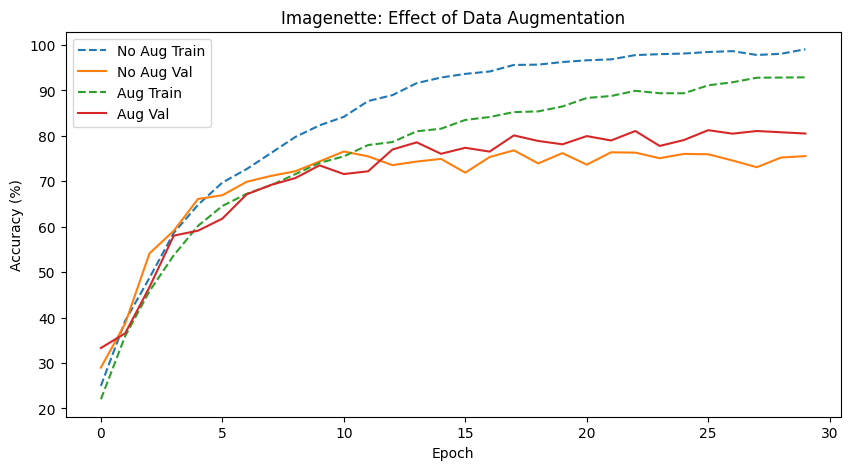


[최종 성능 비교]
                Case  Final_Val_Acc
0    No Augmentation      75.541401
1  With Augmentation      80.509554


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from fastai.data.external import untar_data, URLs
import matplotlib.pyplot as plt
import pandas as pd

# 1. 데이터 준비 (Imagenette)
path = untar_data(URLs.IMAGENETTE_160)

# 증강 없음: Resize + CenterCrop (표준 테스트)
transform_no_aug = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 증강 있음: RandomCrop + Flip
transform_aug = transforms.Compose([
    transforms.Resize((180, 180)), # 조금 더 크게 리사이즈 후 크롭
    transforms.RandomCrop((160, 160)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 데이터셋 로드
train_ds_no = datasets.ImageFolder(path / 'train', transform=transform_no_aug)
train_ds_aug = datasets.ImageFolder(path / 'train', transform=transform_aug)
val_ds = datasets.ImageFolder(path / 'val', transform=transform_no_aug)

# 2. 학습 함수 (이전과 동일)
def train_and_eval(train_ds, name):
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.vgg11(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

    results = {'train_acc': [], 'val_acc': []}

    for epoch in range(30):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
        results['train_acc'].append(100 * correct / total)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, pred = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        results['val_acc'].append(100 * correct / total)
        print(f"{name} Epoch {epoch+1} - Train: {results['train_acc'][-1]:.2f}%, Val: {results['val_acc'][-1]:.2f}%")
    return results

# 3. 실험 실행
results_no_aug = train_and_eval(train_ds_no, "No Aug")
results_aug = train_and_eval(train_ds_aug, "With Aug")

# 4. 시각화 및 최종 성능 표 출력
plt.figure(figsize=(10, 5))
plt.plot(results_no_aug['train_acc'], label='No Aug Train', linestyle='--')
plt.plot(results_no_aug['val_acc'], label='No Aug Val')
plt.plot(results_aug['train_acc'], label='Aug Train', linestyle='--')
plt.plot(results_aug['val_acc'], label='Aug Val')
plt.title('Imagenette: Effect of Data Augmentation')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.show()

# 최종 성능 정리
df = pd.DataFrame({
    'Case': ['No Augmentation', 'With Augmentation'],
    'Final_Val_Acc': [results_no_aug['val_acc'][-1], results_aug['val_acc'][-1]]
})
print("\n[최종 성능 비교]")
print(df)